In [60]:
# Load the packages
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
from torch.utils.data import DataLoader
import torch
import torch.nn as nn

## Step 1 Load Train and Test Split

In [4]:
def load_official_splits(plantvillage_path):
    """
    Load the official Plant village train and test split using image paths

    Parameters
    ------------
    plantvillage_path: str or path
        Root directory of the PlantVillage dataset.

    Returns
    -----------
    train_paths: list
        Relative path of training images

    test_paths: list
        Relative path of testing images
    """
    plantvillage_path = Path(plantvillage_path)

    train_file = plantvillage_path / "splits" / "color_train.txt"
    test_file = plantvillage_path / "splits" / "color_test.txt"

    if not train_file.exists():
        return FileNotFoundError(f"Train Split Not Found: {train_file}")
    if not test_file.exists():
        return FileNotFoundError(f"Test Split not Found: {test_file}")
    with open(train_file,"r") as f:
        train_paths = [line.strip() for line in f if line.strip()]
    with open(test_file,"r") as f:
        test_paths = [line.strip() for line in f if line.strip()]

    return train_paths,test_paths
    

In [5]:
plantVillagePath = Path("../data/raw/plantvillage")
train_paths, test_paths = load_official_splits(plantvillage_path=plantVillagePath)

In [6]:
print("Number of training images :", len(train_paths))
print("Number of testing images :",len(test_paths))
print("\nFirst 3 training paths:")
for path in train_paths[:3]:
    print(path)
print("\nFirst 3 test paths:")
for path in test_paths[:3]:
    print(path)

Number of training images : 43596
Number of testing images : 10709

First 3 training paths:
raw/color/Raspberry___healthy/a37f34f7-022d-461a-8a3d-95f5cd774e35___Mary_HL 9155.JPG
raw/color/Raspberry___healthy/368f3c83-5bd2-4906-b418-57b6ceff9bfe___Mary_HL 9160.JPG
raw/color/Raspberry___healthy/98226f66-15a1-40d5-9b62-04ae5b4fd8d5___Mary_HL 9159.JPG

First 3 test paths:
raw/color/Raspberry___healthy/6c2e049f-38c9-42c5-864f-613e6e12d59e___Mary_HL 6318.JPG
raw/color/Raspberry___healthy/8e8297fd-5e23-44f2-be98-92f7b8908f81___Mary_HL 6315.JPG
raw/color/Raspberry___healthy/67cff824-a58b-40c3-93a2-7dead429b1f0___Mary_HL 6322.JPG


## Step 2 Create Validation Split

In [7]:
## Getting the label from the path for stratified sampling
def get_labels_from_paths(paths):
    """
    Extract class labels from image paths.
    The parent directory represents the class
    """
    return [
        Path(path).parent.name for path in paths
    ]

train_labels = get_labels_from_paths(train_paths)
print(train_labels[:5])
print("Number of labels:", len(train_labels))

['Raspberry___healthy', 'Raspberry___healthy', 'Raspberry___healthy', 'Raspberry___healthy', 'Raspberry___healthy']
Number of labels: 43596


In [8]:
def create_train_val_split(
        train_paths,
        validation_split = 0.2,
        random_state=42
):
    """
    Create  a stratified train/validation split.

    Parameters
    -------------
    train_paths: list
        Official training image paths.
    validation_size: float
        Fraction of training data used for validation.
    random_state: int
        Send for reproducibility. 

    Returns
    ---------
    train_split: list
        Paths used for model training.
    val_split: list
        Paths used for validation. 
    """
    labels = get_labels_from_paths(train_paths)
    train_split,val_split = train_test_split(
        train_paths,
        test_size=validation_split,
        random_state=random_state,
        stratify=labels
    )
    return train_split, val_split

In [11]:
train_split, val_split = create_train_val_split(train_paths)

In [12]:
print("Original train:",len(train_paths))
print("New train:",len(train_split))
print("Validation:",len(val_split))
print("Test:",len(test_paths))

Original train: 43596
New train: 34876
Validation: 8720
Test: 10709


In [13]:
train_set = set(train_split)
val_set = set(val_split)

print("Train ∩ Validation:",
      len(train_set.intersection(val_set)))

print("Train + Validation:",
      len(train_set) + len(val_set))

Train ∩ Validation: 0
Train + Validation: 43596


In [14]:
from collections import Counter
train_distribution = Counter(get_labels_from_paths(train_split))
val_distribution = Counter(get_labels_from_paths(val_split))
for class_name in sorted(train_distribution):
    print(
        f"{class_name:55s} "
        f"Train: {train_distribution[class_name]:5d}"
        f"Val: {val_distribution[class_name]:5d}"
    )

Apple___Apple_scab                                      Train:   402Val:   101
Apple___Black_rot                                       Train:   380Val:    95
Apple___Cedar_apple_rust                                Train:   178Val:    45
Apple___healthy                                         Train:  1087Val:   272
Blueberry___healthy                                     Train:   942Val:   236
Cherry_(including_sour)___Powdery_mildew                Train:   666Val:   167
Cherry_(including_sour)___healthy                       Train:   585Val:   146
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      Train:   325Val:    81
Corn_(maize)___Common_rust_                             Train:   780Val:   195
Corn_(maize)___Northern_Leaf_Blight                     Train:   612Val:   153
Corn_(maize)___healthy                                  Train:   730Val:   182
Grape___Black_rot                                       Train:   810Val:   202
Grape___Esca_(Black_Measles)                        

## Step 3 Define Transformation

In [22]:
def create_transforms(image_size=(224,224)):
    normalize = transforms.Normalize(
        mean = [0.485,0.456,0.406],
        std = [0.229,0.224,0.225]
    )
    train_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2
        ),
        transforms.ToTensor(),
        normalize
    ])
    eval_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        normalize
    ])
    return train_transform, eval_transform

In [23]:
train_transform, eval_transform = create_transforms()

In [24]:
print(train_transform)
print(eval_transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Step 4 Understand Augmentation Visually

In [25]:
## Create the class mapping
def create_class_mapping(paths):
    classes = sorted({
        Path(path).parent.name
        for path in paths
    })
    class_to_idx = {
        class_name: idx for idx, class_name in enumerate(classes)
    }
    idx_to_class = {
        idx:class_name
        for class_name, idx in class_to_idx.items()
    }
    return class_to_idx, idx_to_class

In [26]:
class_to_idx, idx_to_class = create_class_mapping(train_paths)

In [27]:
print("Number of classes:", len(class_to_idx))
print("\nFirst 10 classes:")
for class_name, idx in list(class_to_idx.items())[:10]:
    print(idx,"-",class_name)

Number of classes: 38

First 10 classes:
0 - Apple___Apple_scab
1 - Apple___Black_rot
2 - Apple___Cedar_apple_rust
3 - Apple___healthy
4 - Blueberry___healthy
5 - Cherry_(including_sour)___Powdery_mildew
6 - Cherry_(including_sour)___healthy
7 - Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 - Corn_(maize)___Common_rust_
9 - Corn_(maize)___Northern_Leaf_Blight


In [38]:
class CropDataset(Dataset):

    def __init__(
        self,
        image_paths,
        plantvillage_path,
        class_to_idx,
        transform=None
    ):
        self.image_paths = image_paths
        self.plantvillage_path = Path(plantvillage_path)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        relative_path = self.image_paths[index]

        image_path = self.plantvillage_path / relative_path

        image = Image.open(image_path).convert("RGB")

        class_name = Path(relative_path).parent.name

        label = self.class_to_idx[class_name]

        if self.transform:
            image = self.transform(image)

        return image, label

In [39]:
train_dataset = CropDataset(
    image_paths=train_split,
    plantvillage_path=plantVillagePath,
    class_to_idx=class_to_idx,
    transform=train_transform
)

In [40]:
val_dataset = CropDataset(
    image_paths=val_split,
    plantvillage_path=plantVillagePath,
    class_to_idx=class_to_idx,
    transform=eval_transform
)

In [41]:
test_dataset = CropDataset(
    image_paths=test_paths,
    plantvillage_path=plantVillagePath,
    class_to_idx=class_to_idx,
    transform=eval_transform
)

In [42]:
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 34876
Validation: 8720
Test: 10709


In [43]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Label:", label)
print("Class:", idx_to_class[label])

Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Label: 15
Class: Orange___Haunglongbing_(Citrus_greening)


In [44]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Label:", label)
print("Class:", idx_to_class[label])

Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Label: 15
Class: Orange___Haunglongbing_(Citrus_greening)


In [45]:
print(type(image))
print(type(label))

<class 'torch.Tensor'>
<class 'int'>


In [46]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

34876
8720
10709


## Step 5 Build Data Loaders

In [48]:
def create_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset,
    batch_size=32,
    num_workers=0
):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )
    return train_loader, val_loader, test_loader

In [49]:
train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset,val_dataset,test_dataset
)

In [50]:
images, labels = next(iter(train_loader))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("Images dtype:", images.dtype)
print("Labels dtype:", labels.dtype)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Images dtype: torch.float32
Labels dtype: torch.int64


In [51]:
print(labels)

tensor([35, 35, 13,  6, 20, 24, 24,  5, 15, 31, 31, 24, 19, 28, 26, 10,  9, 20,
        28, 18,  7, 18, 24, 24, 18, 30, 35, 24, 28, 34,  1, 25])


In [52]:
for label in labels[:5]:
    print(label.item(), "→", idx_to_class[label.item()])

35 → Tomato___Tomato_Yellow_Leaf_Curl_Virus
35 → Tomato___Tomato_Yellow_Leaf_Curl_Virus
13 → Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
6 → Cherry_(including_sour)___healthy
20 → Potato___Early_blight


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..1.0980393].


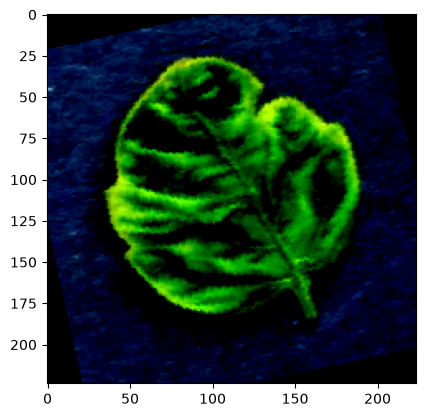

In [53]:
plt.imshow(images[0].permute(1, 2, 0))

In [55]:
def denormalize(image):
    mean = torch.tensor(
        [0.485,0.456,0.406]
    ).view(3,1,1)
    std = torch.tensor(
        [0.229,0.224,0.225]
    ).view(3,1,1)
    return image * std * mean

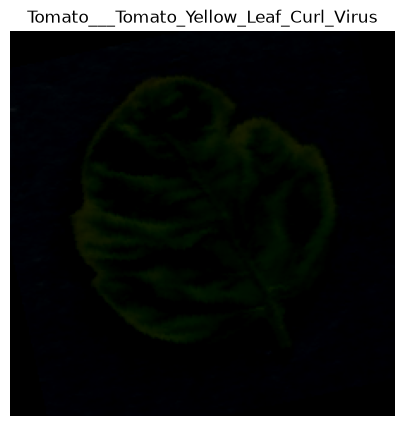

In [59]:
import matplotlib.pyplot as plt
image = denormalize(images[0])
plt.figure(figsize=(5,5))
plt.imshow(image.permute(1,2,0).clamp(0,1))
plt.title(idx_to_class[labels[0].item()])
plt.axis("off")
plt.show()

### First CNN Architecture

### Our First CNN Architecture

Input
3 × 224 × 224
      ↓

Conv2D
3 → 32
      ↓

ReLU
      ↓

MaxPool

      ↓

Conv2D

32 → 64
      ↓

ReLU
      ↓

MaxPool
      ↓

Conv2D
64 → 128
      ↓

ReLU
      ↓

MaxPool
      ↓

Flatten
      ↓

Linear
      ↓

ReLU
      ↓

Linear
      ↓

38 classes

### CNN Layer Wise Learning

Layer 1
  ↓
edges

Layer 2
  ↓
textures / shapes

Layer 3
  ↓
leaf structures / disease patterns

Later layers
  ↓
class-specific visual features

In [63]:
class CropCNN(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                128 * 28 * 28,
                256
            ),
            nn.ReLU(),
            nn.Linear(
                256,
                num_classes
            )
        )
    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [114]:
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

model = CropCNN(num_classes=38)

model = model.to(device)



In [115]:
print(next(model.parameters()).device)

mps:0


In [116]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [132]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        predictions = outputs.argmax(dim=1)
        correct += (predictions==labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss/len(train_loader)
    epoch_accuracy = correct/total
    return epoch_loss,epoch_accuracy

In [125]:
def validate_one_epoch(model, val_loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / len(val_loader)
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [133]:
images = images.to(device)

In [122]:
train_loss, train_accuracy = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

In [126]:
val_loss, val_accuracy = validate_one_epoch(
    model,
    val_loader,
    criterion,
    device
)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

Validation Loss: 0.6301936370767517
Validation Accuracy: 0.8114678899082569


In [134]:
model = CropCNN(num_classes=38).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [135]:
import time

num_epochs = 5

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "epoch_time": []
}

total_start = time.time()

for epoch in range(num_epochs):

    epoch_start = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    epoch_time = time.time() - epoch_start

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["epoch_time"].append(epoch_time)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

total_time = time.time() - total_start

print(f"\nTotal training time: {total_time / 60:.2f} minutes")

Epoch [1/5] Train Loss: 1.2020 | Train Acc: 0.6547 | Val Loss: 0.5768 | Val Acc: 0.8220 | Time: 227.65s
Epoch [2/5] Train Loss: 0.5444 | Train Acc: 0.8321 | Val Loss: 0.4462 | Val Acc: 0.8633 | Time: 245.50s
Epoch [3/5] Train Loss: 0.3840 | Train Acc: 0.8801 | Val Loss: 0.3510 | Val Acc: 0.8865 | Time: 237.59s
Epoch [4/5] Train Loss: 0.2928 | Train Acc: 0.9080 | Val Loss: 0.3196 | Val Acc: 0.8964 | Time: 231.68s
Epoch [5/5] Train Loss: 0.2374 | Train Acc: 0.9232 | Val Loss: 0.2435 | Val Acc: 0.9249 | Time: 249.72s

Total training time: 19.87 minutes


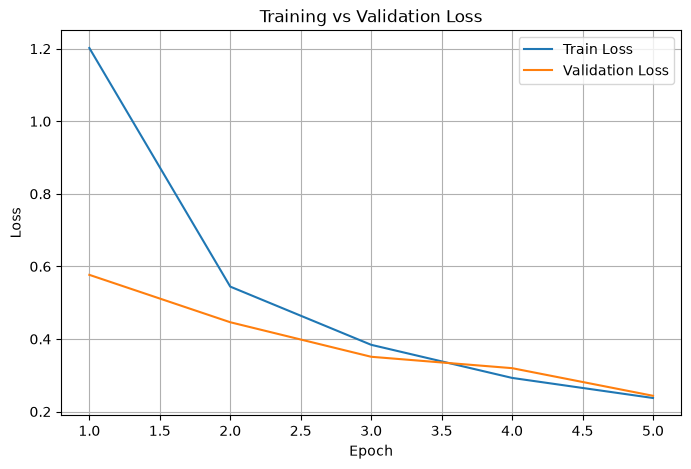

In [136]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

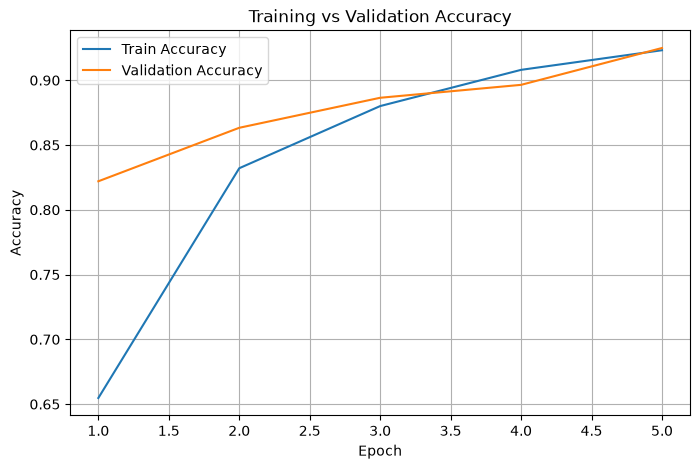

In [137]:
plt.figure(figsize=(8, 5))

plt.plot(epochs, history["train_accuracy"], label="Train Accuracy")
plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [138]:
def evaluate_model(model, test_loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    test_loss = running_loss / len(test_loader)
    test_accuracy = correct / total

    return (
        test_loss,
        test_accuracy,
        all_labels,
        all_predictions
    )

In [139]:
test_loss, test_accuracy, y_true, y_pred = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.3093
Test Accuracy: 0.9090


In [140]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion matrix shape:", cm.shape)

Confusion matrix shape: (38, 38)


In [148]:
import torch
from pathlib import Path

checkpoint = {
    "epoch": 5,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class,
    "num_classes": 38,
    "image_size": (224, 224),
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
}

model_path = Path("../models/cnn/crop_doctor_baseline.pth")

model_path.parent.mkdir(parents=True, exist_ok=True)

torch.save(checkpoint, model_path)

print(f"Checkpoint saved to: {model_path}")
print(f"File exists: {model_path.exists()}")

Checkpoint saved to: ../models/cnn/crop_doctor_baseline.pth
File exists: True


In [149]:
checkpoint = torch.load(
    model_path,
    map_location="cpu"
)

print(checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'class_to_idx', 'idx_to_class', 'num_classes', 'image_size', 'test_accuracy', 'test_loss', 'macro_f1', 'weighted_f1'])


In [150]:
import time

start = time.time()

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

end = time.time()

print(f"Data loading + transfer time: {end - start:.2f} seconds")

Data loading + transfer time: 38.22 seconds


In [151]:
import time

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

# Warm-up MPS
for _ in range(5):
    optimizer.zero_grad(set_to_none=True)
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()

torch.mps.synchronize()

start = time.time()

for _ in range(20):

    optimizer.zero_grad(set_to_none=True)

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

torch.mps.synchronize()

elapsed = time.time() - start

print(f"20 forward + backward passes: {elapsed:.2f}s")
print(f"Average per batch: {elapsed / 20:.2f}s")

20 forward + backward passes: 2.28s
Average per batch: 0.11s


In [152]:
import time

# Training timing
start = time.time()

train_loss, train_accuracy = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

torch.mps.synchronize()

train_time = time.time() - start

print(f"Training time: {train_time:.2f}s")


# Validation timing
start = time.time()

val_loss, val_accuracy = validate_one_epoch(
    model,
    val_loader,
    criterion,
    device
)

torch.mps.synchronize()

val_time = time.time() - start

print(f"Validation time: {val_time:.2f}s")

print(f"Total: {train_time + val_time:.2f}s")

Training time: 184.89s
Validation time: 19.33s
Total: 204.22s


In [153]:
class CropDoctorCNNV2(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [154]:
model_v2 = CropDoctorCNNV2(num_classes=38).to(device)

In [155]:
v2_params = sum(
    p.numel()
    for p in model_v2.parameters()
    if p.requires_grad
)

print("V2 trainable parameters:", v2_params)

V2 trainable parameters: 98150


In [156]:
baseline_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("V1 parameters:", baseline_params)
print("V2 parameters:", v2_params)

V1 parameters: 25793382
V2 parameters: 98150


In [157]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs_v2 = model_v2(images)

print("Input :", images.shape)
print("Output:", outputs_v2.shape)

Input : torch.Size([32, 3, 224, 224])
Output: torch.Size([32, 38])


In [158]:
v1_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

v2_params = sum(
    p.numel()
    for p in model_v2.parameters()
    if p.requires_grad
)

print(f"V1 parameters: {v1_params:,}")
print(f"V2 parameters: {v2_params:,}")
print(f"Reduction: {(1 - v2_params / v1_params) * 100:.2f}%")

V1 parameters: 25,793,382
V2 parameters: 98,150
Reduction: 99.62%


In [ ]:
import time
import torch

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

criterion = nn.CrossEntropyLoss()
f
optimizer_v1 = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# Warm-up
for _ in range(5):
    optimizer_v1.zero_grad(set_to_none=True)
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer_v1.step()

torch.mps.synchronize()

start = time.time()

for _ in range(20):
    optimizer_v1.zero_grad(set_to_none=True)

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer_v1.step()

torch.mps.synchronize()

v1_time = time.time() - start

print(f"V1 - 20 steps: {v1_time:.2f}s")
print(f"V1 - per step: {v1_time / 20:.4f}s")

V1 - 20 steps: 2.70s
V1 - per step: 0.1351s


In [160]:
optimizer_v2 = torch.optim.Adam(
    model_v2.parameters(),
    lr=0.001
)

In [161]:
# Warm-up
for _ in range(5):
    optimizer_v2.zero_grad(set_to_none=True)
    outputs = model_v2(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer_v2.step()

torch.mps.synchronize()

start = time.time()

for _ in range(20):
    optimizer_v2.zero_grad(set_to_none=True)

    outputs = model_v2(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer_v2.step()

torch.mps.synchronize()

v2_time = time.time() - start

print(f"V2 - 20 steps: {v2_time:.2f}s")
print(f"V2 - per step: {v2_time / 20:.4f}s")

V2 - 20 steps: 2.19s
V2 - per step: 0.1093s


In [162]:
print(f"Speed improvement: {v1_time / v2_time:.2f}x")

Speed improvement: 1.24x


In [163]:
model_v2 = CropDoctorCNNV2(num_classes=38).to(device)

criterion_v2 = nn.CrossEntropyLoss()

optimizer_v2 = torch.optim.Adam(
    model_v2.parameters(),
    lr=0.001
)

In [164]:
history_v2 = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "epoch_time": []
}

In [165]:
model_v2 = CropDoctorCNNV2(num_classes=38).to(device)

criterion_v2 = nn.CrossEntropyLoss()

optimizer_v2 = torch.optim.Adam(
    model_v2.parameters(),
    lr=0.001
)

In [166]:
history_v2 = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "epoch_time": []
}

In [167]:
import time

num_epochs = 5

total_start = time.time()

for epoch in range(num_epochs):

    epoch_start = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model_v2,
        train_loader,
        criterion_v2,
        optimizer_v2,
        device
    )

    val_loss, val_accuracy = validate_one_epoch(
        model_v2,
        val_loader,
        criterion_v2,
        device
    )

    epoch_time = time.time() - epoch_start

    history_v2["train_loss"].append(train_loss)
    history_v2["train_accuracy"].append(train_accuracy)
    history_v2["val_loss"].append(val_loss)
    history_v2["val_accuracy"].append(val_accuracy)
    history_v2["epoch_time"].append(epoch_time)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

total_time_v2 = time.time() - total_start

print(f"\nTotal training time: {total_time_v2 / 60:.2f} minutes")

Epoch [1/5] Train Loss: 1.9197 | Train Acc: 0.4626 | Val Loss: 1.1395 | Val Acc: 0.6644 | Time: 177.40s
Epoch [2/5] Train Loss: 1.0974 | Train Acc: 0.6735 | Val Loss: 0.8346 | Val Acc: 0.7421 | Time: 185.87s
Epoch [3/5] Train Loss: 0.8423 | Train Acc: 0.7476 | Val Loss: 0.6675 | Val Acc: 0.7981 | Time: 205.26s
Epoch [4/5] Train Loss: 0.6930 | Train Acc: 0.7910 | Val Loss: 0.5825 | Val Acc: 0.8265 | Time: 211.40s
Epoch [5/5] Train Loss: 0.6023 | Train Acc: 0.8174 | Val Loss: 0.6037 | Val Acc: 0.8144 | Time: 219.91s

Total training time: 16.66 minutes


In [168]:
test_loss_v2, test_accuracy_v2, y_true_v2, y_pred_v2 = evaluate_model(
    model_v2,
    test_loader,
    criterion_v2,
    device
)

print(f"V2 Test Loss: {test_loss_v2:.4f}")
print(f"V2 Test Accuracy: {test_accuracy_v2 * 100:.2f}%")

V2 Test Loss: 0.6479
V2 Test Accuracy: 81.08%


In [169]:
from sklearn.metrics import f1_score

macro_f1_v2 = f1_score(
    y_true_v2,
    y_pred_v2,
    average="macro"
)

weighted_f1_v2 = f1_score(
    y_true_v2,
    y_pred_v2,
    average="weighted"
)

print(f"V2 Macro F1: {macro_f1_v2:.4f}")
print(f"V2 Weighted F1: {weighted_f1_v2:.4f}")

V2 Macro F1: 0.7613
V2 Weighted F1: 0.8030


In [170]:
comparison = {
    "Metric": [
        "Parameters",
        "Test Accuracy",
        "Macro F1",
        "Weighted F1",
        "Test Loss",
        "Training Time"
    ],
    "V1": [
        v1_params,
        test_accuracy,
        macro_f1,
        weighted_f1,
        test_loss,
        sum(history["epoch_time"])
    ],
    "V2": [
        v2_params,
        test_accuracy_v2,
        macro_f1_v2,
        weighted_f1_v2,
        test_loss_v2,
        sum(history_v2["epoch_time"])
    ]
}

comparison

{'Metric': ['Parameters',
  'Test Accuracy',
  'Macro F1',
  'Weighted F1',
  'Test Loss',
  'Training Time'],
 'V1': [25793382,
  0.9090484639088617,
  0.8792724201420048,
  0.9103844181475905,
  0.3093419553232014,
  1192.1401834487915],
 'V2': [98150,
  0.810813334578392,
  0.7612810860854121,
  0.8030001563831074,
  0.6479492612484558,
  999.8513534069061]}